In [1]:
import numpy as np
import copy as cp
import matplotlib as mt
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import MDAnalysis as mda
import scipy as sc
import scipy.optimize as sco
from tqdm import tqdm

/home/jayakrishnak/softwares/anaconda/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### NOE distance restraint pairs 

In [2]:
noe_pairs = [
    [[24,'HB'], [119, 'HE']],     #1
    [[26, 'HD1'], [115, 'HG2']],  #2
    [[26, 'HD1'], [119, 'HE']],   #3
    [[26, 'HD1'], [131, 'HD1']],  #4
    [[29, 'HD2'], [115, 'HG2']],  #5
    [[29, 'HD2'], [119, 'HE']],   #6
    [[29, 'HD2'], [122, 'HD2']],  #7
    [[32, 'HD2'], [119, 'HE']],  #8
    [[32, 'HD2'], [122, 'HD2']],  #9
    [[32, 'HD2'], [130, 'HE']],  #10
    [[32, 'HD2'], [131, 'HD1']],  #11
    [[36, 'HG2'], [122, 'HD2']],  #12
    [[36, 'HG2'], [131, 'HD1']],  #13
    [[43, 'HD1'], [122, 'HD2']],  #14
    [[43, 'HD1'], [130, 'HE']],  #15
    [[111, 'HB'], [119, 'HE']],  #16
    [[115, 'HG2'], [136, 'HG2']], #17
    [[119, 'HE'], [136, 'HG2']], #18
    [[122, 'HD2'], [136, 'HG2']], #19
    [[122, 'HD2'], [143, 'HD2']], #20
    [[32, 'HD2'], [115, 'HG2']], #21
    [[32, 'HD2'], [126, 'HB']], #22
    [[119, 'HE'], [131, 'HD1']], #23
    [[122, 'HD2'], [131, 'HD1']] #24
]

### NOE distance restraints for MD in Nat comm 2022 

In [3]:
noe_exp_md = np.array([11.87, 5.54, 8.59, np.nan, 6.63,
             6.16, 8.89, 4.52, 6.24, np.nan,
             9.65, 8.53, 11.65, 9.42, np.nan,
             10.55, 6.64, 8.76, 8.31, 7.98,
             10.72, 8.53, np.nan, np.nan])

In [4]:
selected = ~np.isnan(noe_exp_md)

### NOE distances calculated from NMR models 8b7i_A1-20

In [5]:
nmodels = 20
noe_models = np.zeros((len(noe_pairs), nmodels))
#
for i in range(nmodels):
    u = mda.Universe(f'nmr_models/8b7i_A{i+1}.pdb')
    #
    for a,p in enumerate(noe_pairs):
        cog1 = np.mean(u.select_atoms(f'resid {p[0][0]} and name {p[0][1]}*').positions, axis=0)
        cog2 = np.mean(u.select_atoms(f'resid {p[1][0]} and name {p[1][1]}*').positions, axis=0)
        noe_models[a,i] = np.linalg.norm(cog1-cog2)

In [6]:
noe_models = np.max(noe_models, axis=1)
noe_models

array([11.83109951,  6.17789793,  8.69462395,  8.53256989,  5.87070704,
        6.19009066,  8.9288826 ,  4.75452948,  6.17241955, 11.12537003,
        9.05768204,  8.81999207, 11.06019688,  9.62316608, 12.81334209,
       10.69595623,  6.30445385,  8.5792942 ,  8.51545906,  8.60244942,
        9.41966152,  9.57467556,  7.62358189,  6.72465038])

### distances from sims

In [6]:
pdb = '../../../0_references/apo_open.pdb'
path = '../../../1_pbc_trajs/individual_trajs/apo_'
trajs = [
    'open_1', 'open_2', 'open_3',
    'closed_1', 'closed_2', 'closed_3'
]

In [16]:
noe_sims = [[] for i in noe_pairs]
#
for t in trajs:
    u = mda.Universe(pdb, f'{path}{t}.xtc')
    #
    for i in tqdm(range(len(u.trajectory))):
        u.trajectory[i]
        #
        for a,p in enumerate(noe_pairs):
            cog1 = np.mean(u.select_atoms(f'resid {p[0][0]} and name *{p[0][1]}*').positions, axis=0)
            cog2 = np.mean(u.select_atoms(f'resid {p[1][0]} and name *{p[1][1]}*').positions, axis=0)
            noe_sims[a].append( np.linalg.norm(cog1-cog2) )

/home/jayakrishnak/softwares/anaconda/lib/python3.9/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400001/400001 [3:24:40<00:00, 32.57it/s]


In [18]:
np.save('saved_noe_/noe_sims.npy', noe_sims)

In [7]:
noe_sims = np.load('save1_saved_noe_/noe_sims.npy').T

In [8]:
noe_sims.shape

(2326523, 24)

In [9]:
mdtrj = np.load('../../5_gateway/3_msm/mdtraj_apo.npy')
mdtrj.shape

(2326523,)

In [10]:
indices = [np.where(mdtrj==i)[0] for i in np.unique(mdtrj)]

In [11]:
pops = {a:np.round(len(i)/mdtrj.shape[0] * 100, 3) for a,i in enumerate(indices)}
pops

{0: 1.45, 1: 12.526, 2: 6.095, 3: 14.987, 4: 17.197, 5: 47.746}

In [12]:
state_labels = ['C', 'C2', 'O', 'C1', 'C3', 'I']

In [19]:
colors = ['salmon', 'dodgerblue', 'forestgreen', 'sienna', 'blueviolet', 'olive']

In [13]:
bins = np.arange(0, 10, 0.01)
xb = bins[1:] - (bins[1]-bins[0])/2

options:

all vs selected violations

exp_md vs max violations

full apo vs metastable states

diff = sim - nmr

diff[np.where(diff < 0)] = 0

np.mean(diff) 

<font size=4>
    $ <viols> = < max(0, NOE_{sim} - NOE_{exp}) >_{N_{viols}} $

### selected exp_md

In [14]:
np.sum(selected)

19

In [15]:
viols = noe_sims[:,selected]
viols.shape

(2326523, 19)

In [16]:
viols = viols - noe_exp_md[selected]
viols[np.where(viols<0)] = 0
viols = np.mean(viols, axis=1)

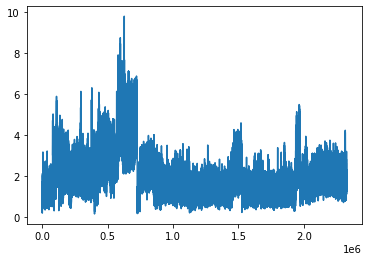

In [103]:
plt.plot(viols)

In [18]:
hists = [
    np.histogram(viols[i], bins=bins)[0]
    for i in indices
]

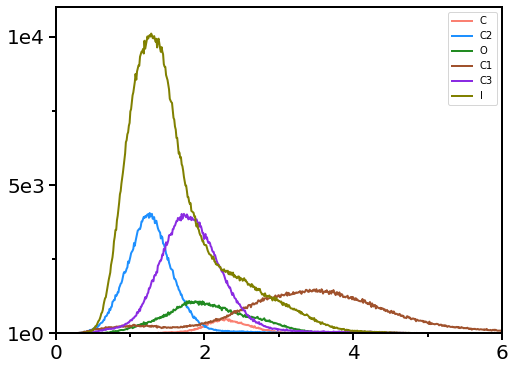

In [36]:
fig, ax = plt.subplots(1, figsize=(8,6))
for a,h in enumerate(hists): 
    ax.plot(xb, h, label=f'{state_labels[a]}', lw=2, color=colors[a])
ax.legend()
ax.set_xlim(0,6)
ax.set_ylim(0,11000)
ax.set_yticks([0,5e3,10e3], ['1e0','5e3','1e4'])
ax.set_xticks([0,2,4,6])
ax.tick_params(labelsize=20, width=2, length=7)
ax.spines[:].set_linewidth(2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=4, width=2)
#
plt.savefig('save1_saved_noe_/noe_sims.pdf')
plt.show()

### all max

In [62]:
viols = noe_sims - noe_models
viols[np.where(viols<0)] = 0
viols = np.mean(viols, axis=1)

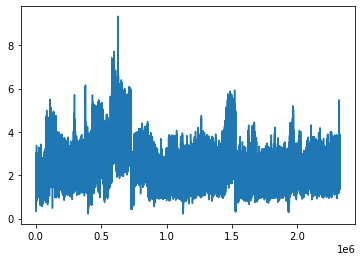

In [63]:
plt.plot(viols)

In [76]:
hists = [
    np.histogram(viols[i], bins=bins)[0]
    for i in indices
]

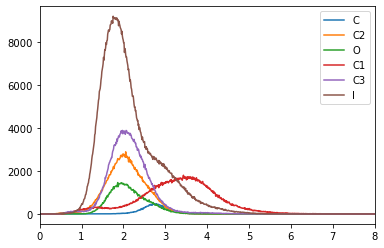

In [87]:
for a,h in enumerate(hists): plt.plot(xb, h, label=f'{state_labels[a]}')
plt.legend()
plt.xlim(0,8)
plt.show()

### selected max

In [119]:
viols = noe_sims[:,selected]
viols.shape

(2326523, 19)

In [120]:
viols = viols - noe_models[selected]
viols[np.where(viols<0)] = 0
viols = np.mean(viols, axis=1)

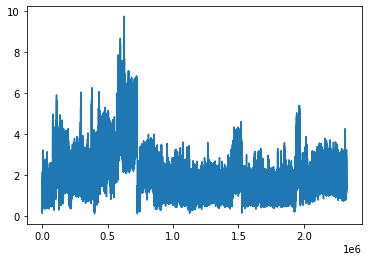

In [121]:
plt.plot(viols)

In [122]:
hists2 = [
    np.histogram(viols[i], bins=bins)[0]
    for i in indices
]

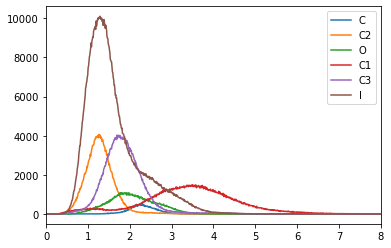

In [130]:
for a,h in enumerate(hists): plt.plot(xb, h, label=f'{state_labels[a]}')
plt.legend()
plt.xlim(0,8)
plt.show()